In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
sessions = pd.read_csv('../data/pre_exp_sessions.csv',
                       parse_dates=['session_start','session_end'])

# PDP sessions only — this is our analysis population
pdp = sessions[sessions['reached_pdp']==True].copy()

print(f"Total sessions:    {len(sessions):,}")
print(f"PDP sessions:      {len(pdp):,}")
print(f"Purchased:         {pdp['purchased'].sum():,}")
print(f"Overall PDP→ATC:   {pdp['reached_atc'].mean():.2%}")
print(f"Overall PDP→Buy:   {pdp['purchased'].mean():.2%}")
display(pdp.head(3))

Total sessions:    29,122
PDP sessions:      7,836
Purchased:         1,418
Overall PDP→ATC:   40.05%
Overall PDP→Buy:   18.10%


,session_id,user_pseudo_id,session_start,session_end,device_category,traffic_source,traffic_medium,item_id,product_category,price_tier,item_price,intent_level,dropoff_reason,category_viewed,order_id,order_revenue,page_view,view_item_list,view_item,add_to_cart,begin_checkout,purchase,avg_scroll_depth,reached_home,reached_plp,reached_pdp,reached_atc,reached_checkout,purchased,pdp_view_count,session_duration_sec,intent_score,is_returned,payment_method
3,sess_uid_000a05c9_20230921153400,uid_000a05c9,2023-09-21 15:34:13,2023-09-21 15:35:28,desktop,email,email,LUM-BDL-03,Bundle,mid,44.990,very_high,out_of_stock,Bundle,NaN,0.000,1,1,1,0,0,0,0.390,True,True,True,False,False,False,1,75.000,5,NaN,NaN
4,sess_uid_000a05c9_20231031183400,uid_000a05c9,2023-10-31 18:34:03,2023-10-31 18:41:35,desktop,email,email,LUM-SH-03,Shampoo,mid,39.990,very_high,converted,Shampoo,NaN,0.000,1,1,2,1,1,0,0.735,True,True,True,True,True,False,2,452.000,5,NaN,NaN
5,sess_uid_000a05c9_20231110073400,uid_000a05c9,2023-11-10 07:34:02,2023-11-10 07:36:37,mobile,direct,none,LUM-BW-01,Body Wash,low,21.990,very_high,converted,Body Wash,NaN,0.000,1,1,1,1,1,0,0.950,True,True,True,True,True,False,1,155.000,5,NaN,NaN


In [3]:
def segment_analysis(df, segment_col, sort_by='pdp_to_atc',
                     min_sessions=30, order=None):
    """
    Compute full funnel metrics for any segment dimension.
    Returns one row per segment value with:
    - Volume, funnel rates, intent, scroll depth,
      drop-off reason distribution, AOV
    """
    grp = (
        df.groupby(segment_col)
        .agg(
            sessions         = (segment_col,          'count'),
            reached_atc      = ('reached_atc',         'sum'),
            purchased        = ('purchased',            'sum'),
            avg_pdp_views    = ('pdp_view_count',      'mean'),
            avg_scroll       = ('avg_scroll_depth',    'mean'),
            avg_dur_sec      = ('session_duration_sec','mean'),
        )
        .reset_index()
    )

    # AOV for purchasers only
    aov = (
        df[df['purchased']==True]
        .groupby(segment_col)['order_revenue']
        .mean().reset_index()
        .rename(columns={'order_revenue':'aov'})
    )
    grp = grp.merge(aov, on=segment_col, how='left')

    # Rates
    grp['pdp_to_atc']  = grp['reached_atc'] / grp['sessions']
    grp['pdp_to_buy']  = grp['purchased']   / grp['sessions']
    grp['avg_dur_min'] = grp['avg_dur_sec'] / 60
    grp['traffic_share'] = grp['sessions']  / grp['sessions'].sum()

    # Filter minimum sessions
    grp = grp[grp['sessions'] >= min_sessions]

    # Sort
    if order:
        grp[segment_col] = pd.Categorical(grp[segment_col], order)
        grp = grp.sort_values(segment_col)
    else:
        grp = grp.sort_values(sort_by, ascending=False)

    return grp


def print_segment_table(df, segment_col, label):
    print(f"\n{'='*65}")
    print(f"SEGMENT: {label}")
    print(f"{'='*65}")
    print(f"\n{'Segment':<22} {'Sessions':>8} {'Share':>6} "
          f"{'PDP→ATC':>8} {'PDP→Buy':>8} "
          f"{'Scroll':>7} {'AOV':>7}")
    print("-" * 65)
    for _, row in df.iterrows():
        aov_str = f"${row['aov']:.0f}" if pd.notna(row['aov']) else "—"
        print(f"{str(row[segment_col]):<22} "
              f"{row['sessions']:>8,} "
              f"{row['traffic_share']:>6.1%} "
              f"{row['pdp_to_atc']:>8.1%} "
              f"{row['pdp_to_buy']:>8.1%} "
              f"{row['avg_scroll']:>7.2f} "
              f"{aov_str:>7}")

print("Helper functions defined ✓")

Helper functions defined ✓


SEGMENT 1 — DEVICE CATEGORY

Device affects conversion because:
  Mobile  → small screen, harder to read specs and trust signals
  Desktop → larger screen, easier to compare and commit
  Tablet  → middle ground


SEGMENT: Device

Segment                Sessions  Share  PDP→ATC  PDP→Buy  Scroll     AOV
-----------------------------------------------------------------
mobile                    4,436  56.6%    37.7%    15.9%    0.55     $43
tablet                      623   8.0%    39.6%    18.6%    0.54     $50
desktop                   2,777  35.4%    43.9%    21.5%    0.55     $44


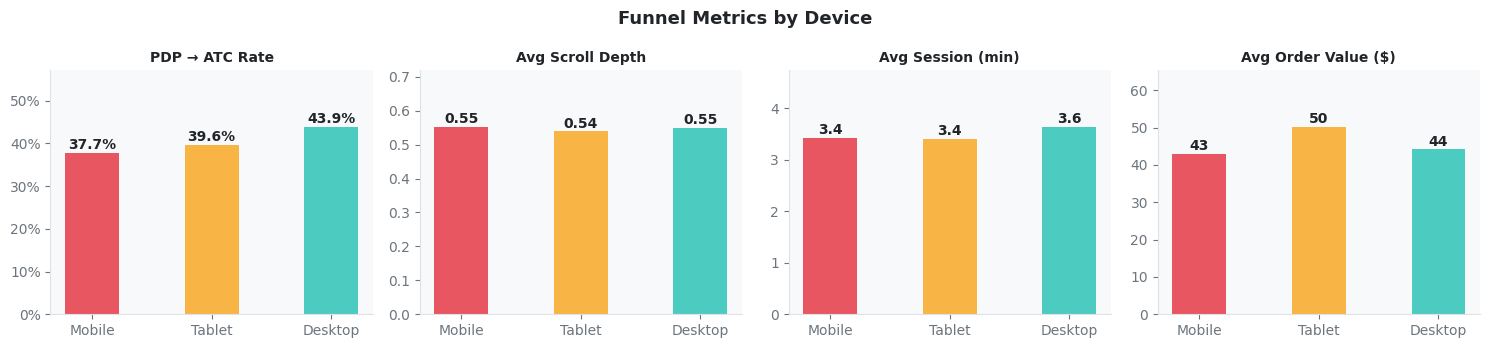


💡 Device Insight:
  Mobile ATC rate:  37.7% vs Desktop: 43.9%
  Gap: 6.2% lower on mobile
  Mobile scroll:    0.55 vs Desktop: 0.55
  Mobile is 56.6% of all PDP sessions


In [4]:
print("=" * 65)
print("SEGMENT 1 — DEVICE CATEGORY")
print("=" * 65)
print("""
Device affects conversion because:
  Mobile  → small screen, harder to read specs and trust signals
  Desktop → larger screen, easier to compare and commit
  Tablet  → middle ground
""")

device_seg = segment_analysis(
    pdp, 'device_category',
    order=['mobile','tablet','desktop']
)
print_segment_table(device_seg, 'device_category', 'Device')

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
fig.suptitle('Funnel Metrics by Device', fontsize=13, fontweight='bold')

device_colors = ['#e63946','#f9a825','#2ec4b6']
metrics = [
    ('pdp_to_atc',  'PDP → ATC Rate',      '.1%'),
    ('avg_scroll',  'Avg Scroll Depth',     '.2f'),
    ('avg_dur_min', 'Avg Session (min)',    '.1f'),
    ('aov',         'Avg Order Value ($)',  '.0f'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    vals = device_seg[col].values
    bars = ax.bar(
        device_seg['device_category'].str.capitalize(),
        vals, color=device_colors, width=0.45, alpha=0.85
    )
    ax.set_title(title, fontsize=10)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            label = f"{v:{fmt}}" if fmt != '.1%' else f"{v:.1%}"
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals)*0.02,
                    label, ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3)
    if fmt == '.1%':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('../data/seg_device.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
mobile  = device_seg[device_seg['device_category']=='mobile'].iloc[0]
desktop = device_seg[device_seg['device_category']=='desktop'].iloc[0]
print(f"\n💡 Device Insight:")
print(f"  Mobile ATC rate:  {mobile['pdp_to_atc']:.1%} vs "
      f"Desktop: {desktop['pdp_to_atc']:.1%}")
print(f"  Gap: {desktop['pdp_to_atc']-mobile['pdp_to_atc']:.1%} lower on mobile")
print(f"  Mobile scroll:    {mobile['avg_scroll']:.2f} vs "
      f"Desktop: {desktop['avg_scroll']:.2f}")
print(f"  Mobile is {mobile['traffic_share']:.1%} of all PDP sessions")

SEGMENT 2 — TRAFFIC SOURCE

Traffic source determines user INTENT before they arrive.
High intent (direct/email) → arrive ready to buy.
Low intent (social) → interrupted while browsing.
Key question: does each source drop off at the SAME stage?


SEGMENT: Traffic Source

Segment                Sessions  Share  PDP→ATC  PDP→Buy  Scroll     AOV
-----------------------------------------------------------------
direct                    1,819  23.2%    46.1%    21.3%    0.57     $44
email                     2,761  35.2%    45.5%    20.1%    0.56     $45
google                    1,796  22.9%    39.9%    18.8%    0.62     $44
referral                    681   8.7%    35.7%    15.6%    0.62     $43
instagram                   626   8.0%    11.5%     4.8%    0.22     $40
tiktok                      153   2.0%     8.5%     2.0%    0.22     $55

Full funnel entry rates by source:

Source        Home→PLP   PLP→PDP
--------------------------------
email            81.9%     64.2%
direct         

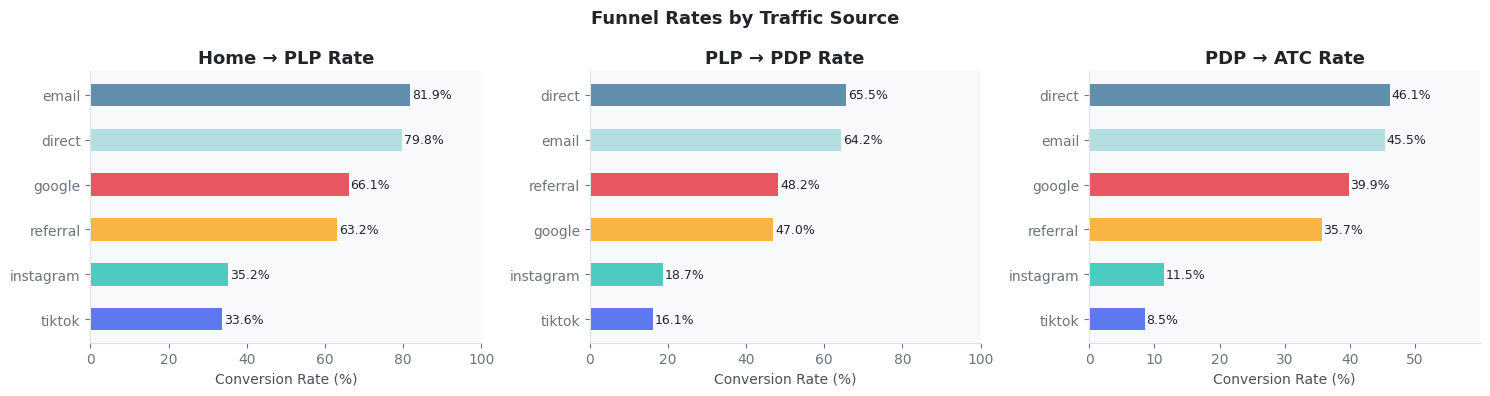


💡 Traffic Source Insights:
  Best CVR:  direct (46.1% ATC)
  Worst CVR: tiktok (8.5% ATC)
  Gap: 37.6%


In [5]:
print("=" * 65)
print("SEGMENT 2 — TRAFFIC SOURCE")
print("=" * 65)
print("""
Traffic source determines user INTENT before they arrive.
High intent (direct/email) → arrive ready to buy.
Low intent (social) → interrupted while browsing.
Key question: does each source drop off at the SAME stage?
""")

source_seg = segment_analysis(pdp, 'traffic_source')
print_segment_table(source_seg, 'traffic_source', 'Traffic Source')

# Also compute Home→PLP rates from full sessions
home_to_plp = (
    sessions.groupby('traffic_source')
    .agg(
        total     = ('traffic_source',  'count'),
        reach_plp = ('reached_plp',     'sum'),
        reach_pdp = ('reached_pdp',     'sum'),
    )
    .reset_index()
)
home_to_plp['h2p_rate'] = home_to_plp['reach_plp'] / home_to_plp['total']
home_to_plp['p2d_rate'] = home_to_plp['reach_pdp'] / home_to_plp['reach_plp']

print(f"\nFull funnel entry rates by source:")
print(f"\n{'Source':<12} {'Home→PLP':>9} {'PLP→PDP':>9}")
print("-" * 32)
for _, row in home_to_plp.sort_values('h2p_rate', ascending=False).iterrows():
    print(f"{row['traffic_source']:<12} "
          f"{row['h2p_rate']:>9.1%} "
          f"{row['p2d_rate']:>9.1%}")

# Visualization — 3 rates side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Funnel Rates by Traffic Source', fontsize=13, fontweight='bold')

palette = ['#4361ee','#2ec4b6','#f9a825','#e63946','#a8dadc','#457b9d']

# Home→PLP
ax = axes[0]
h2p = home_to_plp.sort_values('h2p_rate', ascending=True)
bars = ax.barh(h2p['traffic_source'], h2p['h2p_rate']*100,
               color=palette[:len(h2p)], height=0.5, alpha=0.85)
ax.set_title('Home → PLP Rate')
ax.set_xlabel('Conversion Rate (%)')
for bar, v in zip(bars, h2p['h2p_rate']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{v:.1%}', va='center', fontsize=9)
ax.set_xlim(0, 100)

# PLP→PDP
ax2 = axes[1]
p2d = home_to_plp.sort_values('p2d_rate', ascending=True)
bars2 = ax2.barh(p2d['traffic_source'], p2d['p2d_rate']*100,
                 color=palette[:len(p2d)], height=0.5, alpha=0.85)
ax2.set_title('PLP → PDP Rate')
ax2.set_xlabel('Conversion Rate (%)')
for bar, v in zip(bars2, p2d['p2d_rate']):
    ax2.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{v:.1%}', va='center', fontsize=9)
ax2.set_xlim(0, 100)

# PDP→ATC
ax3 = axes[2]
ss = source_seg.sort_values('pdp_to_atc', ascending=True)
bars3 = ax3.barh(ss['traffic_source'], ss['pdp_to_atc']*100,
                 color=palette[:len(ss)], height=0.5, alpha=0.85)
ax3.set_title('PDP → ATC Rate')
ax3.set_xlabel('Conversion Rate (%)')
for bar, v in zip(bars3, ss['pdp_to_atc']):
    ax3.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{v:.1%}', va='center', fontsize=9)
ax3.set_xlim(0, ss['pdp_to_atc'].max()*130)

plt.tight_layout()
plt.savefig('../data/seg_source.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insights
best_src  = source_seg.iloc[0]
worst_src = source_seg.iloc[-1]
print(f"\n💡 Traffic Source Insights:")
print(f"  Best CVR:  {best_src['traffic_source']} "
      f"({best_src['pdp_to_atc']:.1%} ATC)")
print(f"  Worst CVR: {worst_src['traffic_source']} "
      f"({worst_src['pdp_to_atc']:.1%} ATC)")
print(f"  Gap: {best_src['pdp_to_atc']-worst_src['pdp_to_atc']:.1%}")

SEGMENT 3 — PRODUCT CATEGORY

SEGMENT: Product Category

Segment                Sessions  Share  PDP→ATC  PDP→Buy  Scroll     AOV
-----------------------------------------------------------------
Body Wash                 1,664  21.2%    43.5%    22.7%    0.55     $38
Bundle                    2,327  29.7%    41.2%    15.9%    0.57     $53
Shampoo                   1,843  23.5%    41.2%    18.9%    0.55     $40
Conditioner               1,379  17.6%    38.9%    19.2%    0.54     $41
Value Pack                  623   8.0%    25.5%     9.1%    0.50     $65


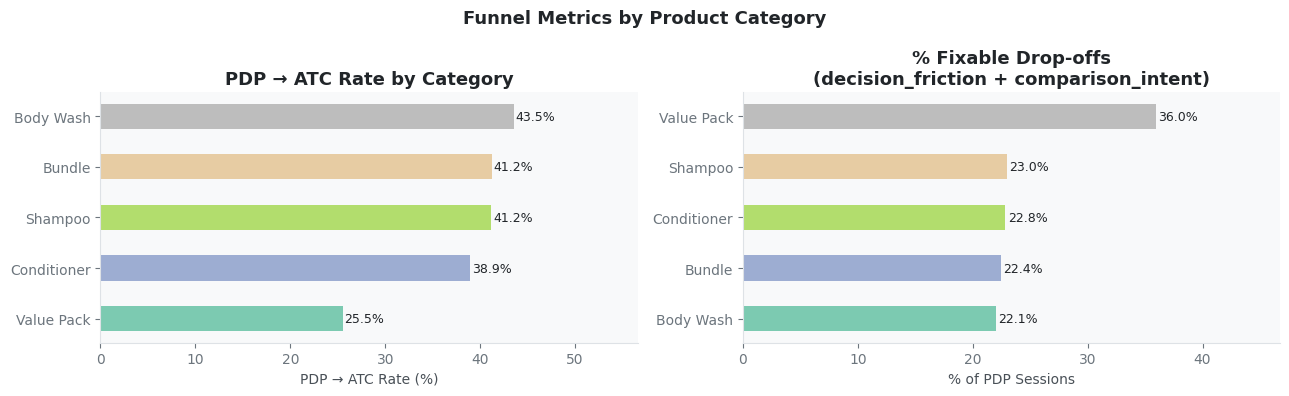

In [6]:
print("=" * 65)
print("SEGMENT 3 — PRODUCT CATEGORY")
print("=" * 65)

cat_seg = segment_analysis(pdp, 'product_category')
print_segment_table(cat_seg, 'product_category', 'Product Category')

# Drop-off reason mix by category
reason_by_cat = (
    pdp.groupby(['product_category','dropoff_reason'])
    .size().reset_index(name='sessions')
)
cat_totals = pdp.groupby('product_category').size()
reason_by_cat['pct'] = reason_by_cat.apply(
    lambda r: r['sessions']/cat_totals[r['product_category']], axis=1)

# Focus on fixable reasons
fixable = ['decision_friction','comparison_intent']
fixable_by_cat = (
    reason_by_cat[reason_by_cat['dropoff_reason'].isin(fixable)]
    .groupby('product_category')['pct'].sum()
    .reset_index()
    .rename(columns={'pct':'fixable_pct'})
    .sort_values('fixable_pct', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Funnel Metrics by Product Category',
             fontsize=13, fontweight='bold')

palette_cat = plt.cm.Set2(np.linspace(0, 1, len(cat_seg)))

# PDP→ATC by category
ax = axes[0]
cs = cat_seg.sort_values('pdp_to_atc', ascending=True)
bars = ax.barh(cs['product_category'], cs['pdp_to_atc']*100,
               color=palette_cat[:len(cs)], height=0.5, alpha=0.85)
ax.set_title('PDP → ATC Rate by Category')
ax.set_xlabel('PDP → ATC Rate (%)')
for bar, v in zip(bars, cs['pdp_to_atc']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{v:.1%}', va='center', fontsize=9)
ax.set_xlim(0, cs['pdp_to_atc'].max()*130)

# Fixable drop-off % by category
ax2 = axes[1]
fc = fixable_by_cat.sort_values('fixable_pct', ascending=True)
bars2 = ax2.barh(fc['product_category'], fc['fixable_pct']*100,
                 color=palette_cat[:len(fc)], height=0.5, alpha=0.85)
ax2.set_title('% Fixable Drop-offs\n(decision_friction + comparison_intent)')
ax2.set_xlabel('% of PDP Sessions')
for bar, v in zip(bars2, fc['fixable_pct']):
    ax2.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{v:.1%}', va='center', fontsize=9)
ax2.set_xlim(0, fc['fixable_pct'].max()*130)

plt.tight_layout()
plt.savefig('../data/seg_category.png', dpi=150, bbox_inches='tight')
plt.show()

SEGMENT 4 — PRICE TIER

Price tier is the most important segment dimension.
High-price products require more trust and confidence.
The A/B test specifically targets high-price drop-off.


SEGMENT: Price Tier

Segment                Sessions  Share  PDP→ATC  PDP→Buy  Scroll     AOV
-----------------------------------------------------------------
low                       4,280  54.6%    41.8%    21.2%    0.55     $39
mid                       2,933  37.4%    40.6%    15.5%    0.56     $52
high                        623   8.0%    25.5%     9.1%    0.50     $65

Drop-off reason mix by price tier:


price_tier,low,mid,high
dropoff_reason,,,
converted,0.412,0.433,0.270
comparison_intent,0.083,0.088,0.250
price_barrier,0.170,0.168,0.141
decision_friction,0.143,0.136,0.109
ad_pdp_mismatch,0.000,0.000,0.085
price_shock,0.030,0.027,0.063
distraction,0.057,0.056,0.034
impulse_faded,0.032,0.026,0.030
wrong_audience,0.020,0.016,0.018


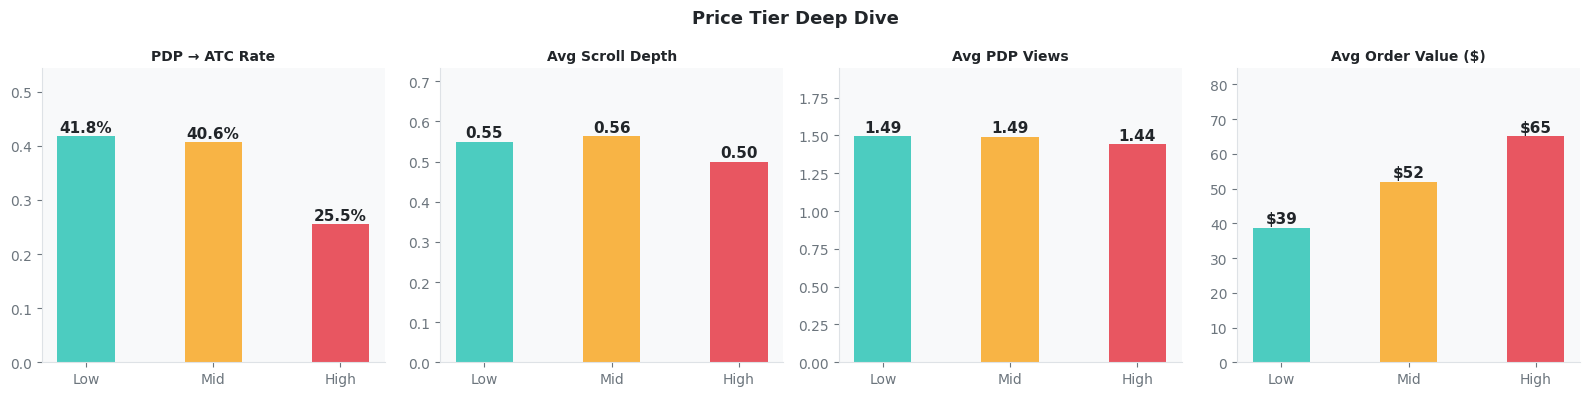

In [7]:
print("=" * 65)
print("SEGMENT 4 — PRICE TIER")
print("=" * 65)
print("""
Price tier is the most important segment dimension.
High-price products require more trust and confidence.
The A/B test specifically targets high-price drop-off.
""")

tier_seg = segment_analysis(
    pdp, 'price_tier', order=['low','mid','high'])
print_segment_table(tier_seg, 'price_tier', 'Price Tier')

# Drop-off reason by tier — detailed breakdown
reason_by_tier = (
    pdp.groupby(['price_tier','dropoff_reason'])
    .size().reset_index(name='sessions')
)
tier_totals = pdp.groupby('price_tier').size()
reason_by_tier['pct'] = reason_by_tier.apply(
    lambda r: r['sessions']/tier_totals[r['price_tier']], axis=1)

pivot = reason_by_tier.pivot(
    index='dropoff_reason',
    columns='price_tier',
    values='pct'
)[['low','mid','high']].fillna(0).sort_values('high', ascending=False)

print(f"\nDrop-off reason mix by price tier:")
display(pivot.round(3))

# Visualization — 4 charts
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Price Tier Deep Dive', fontsize=13, fontweight='bold')

tier_colors = ['#2ec4b6','#f9a825','#e63946']
tier_labels = ['Low','Mid','High']

for ax, (col, title, fmt) in zip(axes, [
    ('pdp_to_atc',  'PDP → ATC Rate',      'pct'),
    ('avg_scroll',  'Avg Scroll Depth',     'dec'),
    ('avg_pdp_views','Avg PDP Views',       'dec'),
    ('aov',         'Avg Order Value ($)',  'dollar'),
]):
    vals  = tier_seg[col].values
    bars  = ax.bar(tier_labels, vals, color=tier_colors,
                   width=0.45, alpha=0.85)
    ax.set_title(title, fontsize=10)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            if fmt == 'pct':    label = f"{v:.1%}"
            elif fmt == 'dec':  label = f"{v:.2f}"
            else:               label = f"${v:.0f}"
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals)*0.02,
                    label, ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3)

plt.tight_layout()
plt.savefig('../data/seg_price_tier.png', dpi=150, bbox_inches='tight')
plt.show()

SEGMENT 5 — INTENT LEVEL (NEW)

Intent level is a new dimension unique to our enriched dataset.
It combines traffic source + price tier + device into one signal.
This is the closest proxy to what the user was thinking when
they arrived — are they ready to buy or just browsing?


SEGMENT: Intent Level

Segment                Sessions  Share  PDP→ATC  PDP→Buy  Scroll     AOV
-----------------------------------------------------------------
very_low                     42   0.5%     7.1%     0.0%    0.22       —
low                         785  10.0%    11.2%     4.6%    0.23     $43
medium                      291   3.7%    18.9%     6.2%    0.48     $69
high                      2,558  32.6%    40.0%    18.3%    0.64     $44
very_high                 4,160  53.1%    47.3%    21.5%    0.57     $44


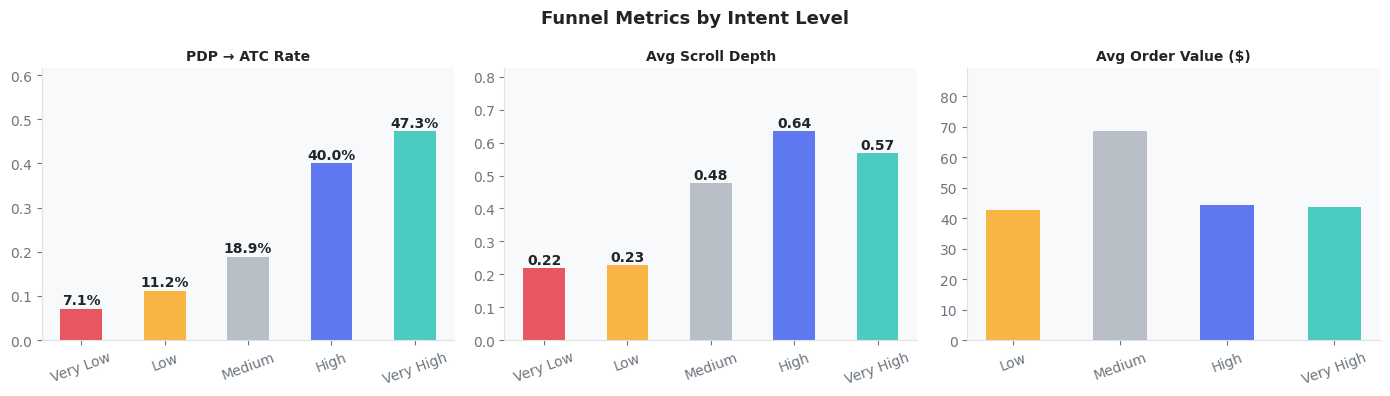


💡 Intent Level Insight:
  Very High intent ATC: 47.3% vs Very Low: 7.1%
  Gap: 40.2%
  Very High scroll: 0.57 vs Very Low: 0.22


In [8]:
print("=" * 65)
print("SEGMENT 5 — INTENT LEVEL (NEW)")
print("=" * 65)
print("""
Intent level is a new dimension unique to our enriched dataset.
It combines traffic source + price tier + device into one signal.
This is the closest proxy to what the user was thinking when
they arrived — are they ready to buy or just browsing?
""")

intent_order = ['very_low','low','medium','high','very_high']
intent_seg   = segment_analysis(
    pdp, 'intent_level', order=intent_order)
print_segment_table(intent_seg, 'intent_level', 'Intent Level')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Funnel Metrics by Intent Level',
             fontsize=13, fontweight='bold')

intent_colors = ['#e63946','#f9a825','#adb5bd','#4361ee','#2ec4b6']

for ax, (col, title, fmt) in zip(axes, [
    ('pdp_to_atc', 'PDP → ATC Rate',   'pct'),
    ('avg_scroll', 'Avg Scroll Depth',  'dec'),
    ('aov',        'Avg Order Value ($)','dollar'),
]):
    seg  = intent_seg.copy()
    vals = seg[col].values
    bars = ax.bar(
        [i.replace('_',' ').title() for i in seg['intent_level']],
        vals, color=intent_colors[:len(seg)], width=0.5, alpha=0.85
    )
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', labelrotation=20)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            if fmt == 'pct':   label = f"{v:.1%}"
            elif fmt == 'dec': label = f"{v:.2f}"
            else:              label = f"${v:.0f}"
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals)*0.02,
                    label, ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, np.nanmax(vals)*1.3)

plt.tight_layout()
plt.savefig('../data/seg_intent.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
vh = intent_seg[intent_seg['intent_level']=='very_high'].iloc[0]
vl = intent_seg[intent_seg['intent_level']=='very_low'].iloc[0]
print(f"\n💡 Intent Level Insight:")
print(f"  Very High intent ATC: {vh['pdp_to_atc']:.1%} "
      f"vs Very Low: {vl['pdp_to_atc']:.1%}")
print(f"  Gap: {vh['pdp_to_atc']-vl['pdp_to_atc']:.1%}")
print(f"  Very High scroll: {vh['avg_scroll']:.2f} "
      f"vs Very Low: {vl['avg_scroll']:.2f}")

DROP-OFF REASON BY SEGMENT (NEW)

Shows the MIX of drop-off reasons varies by segment.
High-price + mobile → more decision_friction
Social traffic     → more impulse_faded + wrong_audience
This tells us WHICH segments benefit most from the A/B treatment.



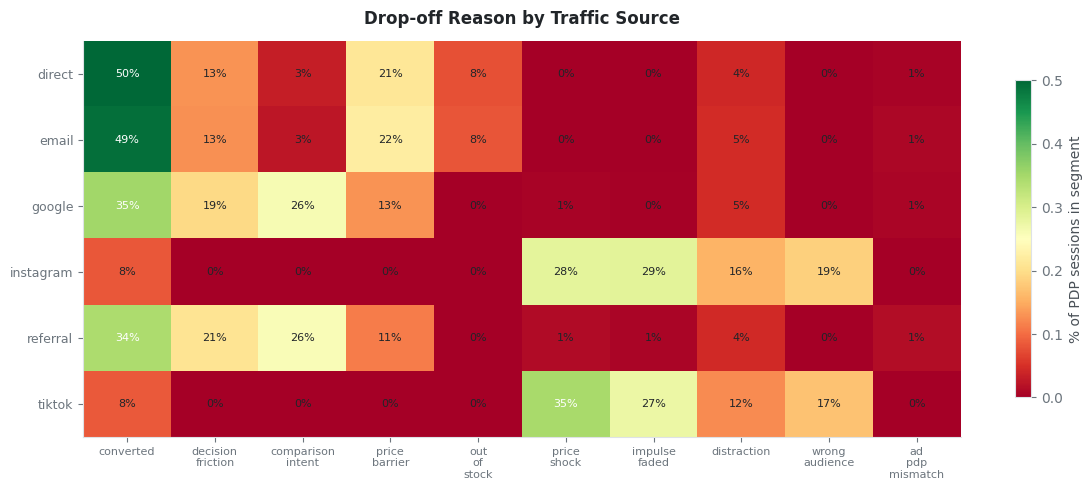

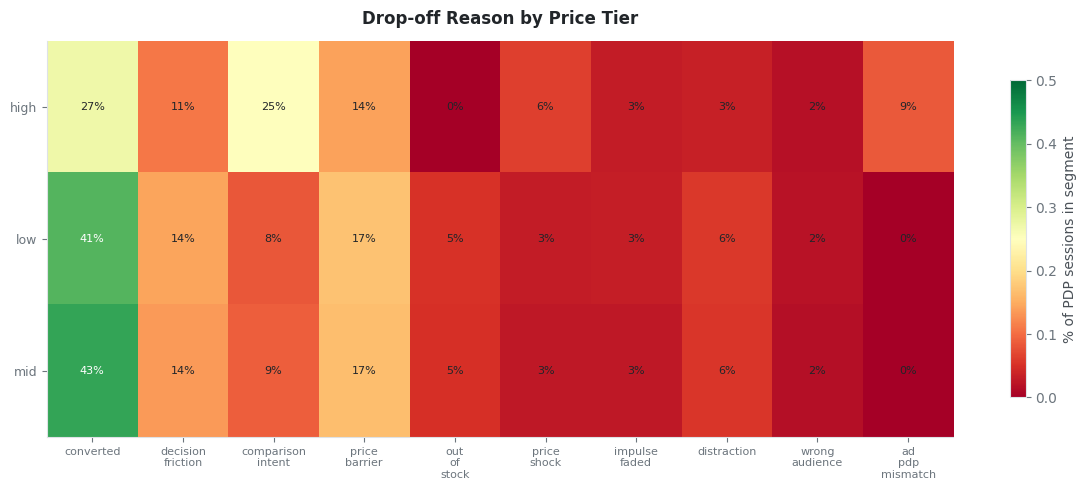

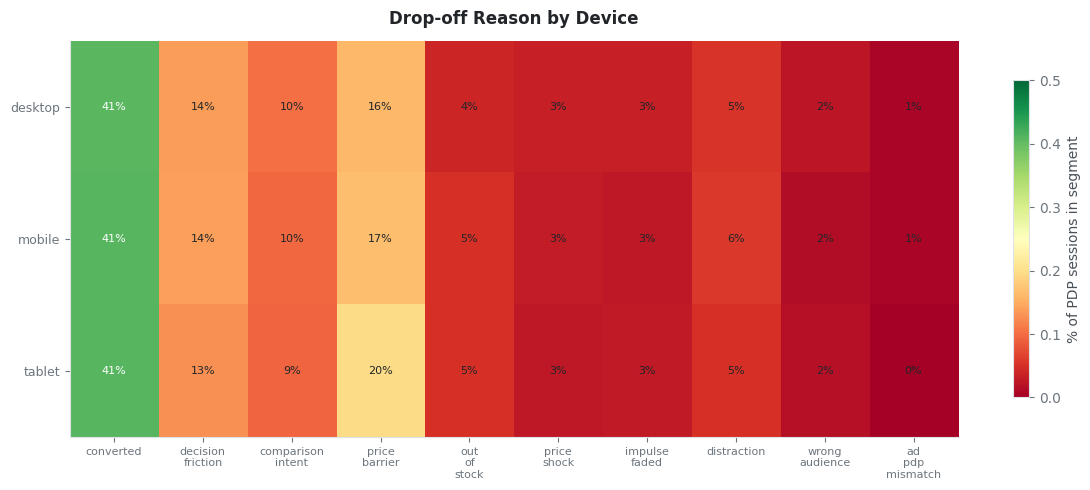

In [9]:
print("=" * 65)
print("DROP-OFF REASON BY SEGMENT (NEW)")
print("=" * 65)
print("""
Shows the MIX of drop-off reasons varies by segment.
High-price + mobile → more decision_friction
Social traffic     → more impulse_faded + wrong_audience
This tells us WHICH segments benefit most from the A/B treatment.
""")

# Drop-off reason by traffic source
def dropoff_heatmap(df, segment_col, title, figsize=(12,5)):
    reason_seg = (
        df.groupby([segment_col,'dropoff_reason'])
        .size().reset_index(name='sessions')
    )
    seg_totals = df.groupby(segment_col).size()
    reason_seg['pct'] = reason_seg.apply(
        lambda r: r['sessions']/seg_totals[r[segment_col]], axis=1)

    pivot = reason_seg.pivot(
        index=segment_col,
        columns='dropoff_reason',
        values='pct'
    ).fillna(0)

    # Order reasons
    reason_order = [
        'converted','decision_friction','comparison_intent',
        'price_barrier','out_of_stock','price_shock',
        'impulse_faded','distraction','wrong_audience','ad_pdp_mismatch'
    ]
    reason_order = [r for r in reason_order if r in pivot.columns]
    pivot = pivot[reason_order]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=0, vmax=0.5)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(
        [c.replace('_','\n') for c in pivot.columns],
        fontsize=8, rotation=0
    )
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i,j]
            color = 'white' if val > 0.30 else '#212529'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=8, color=color)

    plt.colorbar(im, ax=ax, label='% of PDP sessions in segment',
                 shrink=0.8)
    plt.tight_layout()
    return fig

fig1 = dropoff_heatmap(
    pdp, 'traffic_source',
    'Drop-off Reason by Traffic Source')
plt.savefig('../data/dropoff_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = dropoff_heatmap(
    pdp, 'price_tier',
    'Drop-off Reason by Price Tier')
plt.savefig('../data/dropoff_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

fig3 = dropoff_heatmap(
    pdp, 'device_category',
    'Drop-off Reason by Device')
plt.savefig('../data/dropoff_by_device.png', dpi=150, bbox_inches='tight')
plt.show()

SCROLL DEPTH BY SEGMENT (NEW)


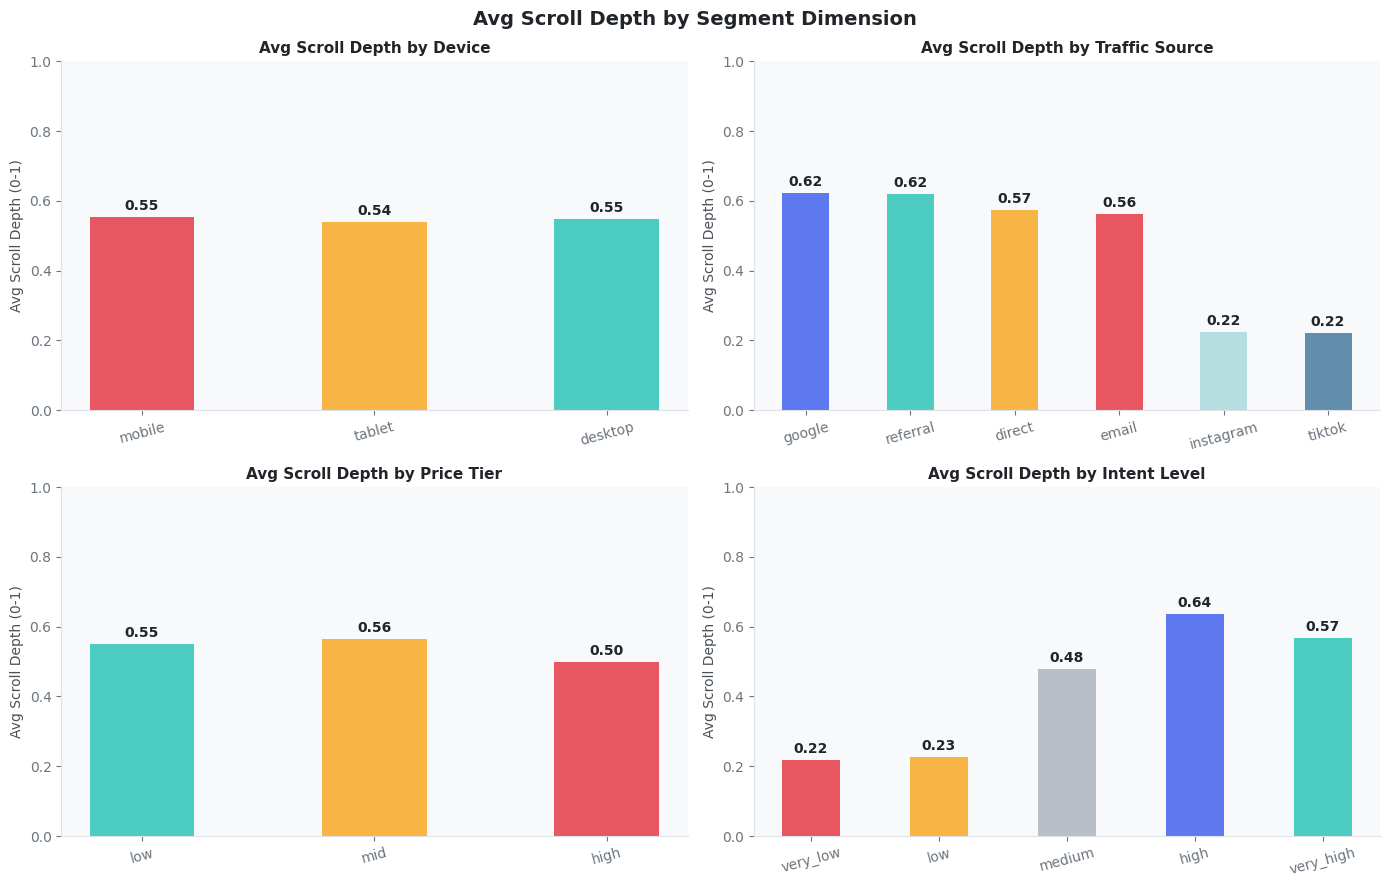

In [10]:
print("=" * 65)
print("SCROLL DEPTH BY SEGMENT (NEW)")
print("=" * 65)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Avg Scroll Depth by Segment Dimension',
             fontsize=14, fontweight='bold')

segment_dims = [
    ('device_category', ['mobile','tablet','desktop'],   'Device'),
    ('traffic_source',  None,                            'Traffic Source'),
    ('price_tier',      ['low','mid','high'],            'Price Tier'),
    ('intent_level',    intent_order,                    'Intent Level'),
]

colors_map = {
    'device_category': ['#e63946','#f9a825','#2ec4b6'],
    'traffic_source' : ['#4361ee','#2ec4b6','#f9a825',
                        '#e63946','#a8dadc','#457b9d'],
    'price_tier'     : ['#2ec4b6','#f9a825','#e63946'],
    'intent_level'   : ['#e63946','#f9a825','#adb5bd',
                        '#4361ee','#2ec4b6'],
}

for ax, (col, order, label) in zip(axes.flatten(), segment_dims):
    scroll_seg = (
        pdp.groupby(col)['avg_scroll_depth']
        .mean().reset_index()
        .rename(columns={'avg_scroll_depth':'avg_scroll'})
    )
    if order:
        scroll_seg[col] = pd.Categorical(scroll_seg[col], order)
        scroll_seg = scroll_seg.sort_values(col)
    else:
        scroll_seg = scroll_seg.sort_values('avg_scroll', ascending=False)

    clrs = colors_map.get(col, ['#4361ee']*len(scroll_seg))
    bars = ax.bar(
        scroll_seg[col].astype(str),
        scroll_seg['avg_scroll'],
        color=clrs[:len(scroll_seg)], width=0.45, alpha=0.85
    )
    ax.set_title(f'Avg Scroll Depth by {label}', fontsize=11)
    ax.set_ylabel('Avg Scroll Depth (0-1)')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', labelrotation=15)
    for bar, v in zip(bars, scroll_seg['avg_scroll']):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.02,
                f'{v:.2f}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/scroll_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

CROSS-TAB: SOURCE × PRICE TIER × DEVICE

The most granular segmentation in the analysis.
Identifies the specific intersection of:
  source × price tier × device
that has the worst PDP→ATC conversion.
This becomes the primary target audience for the A/B test.


BOTTOM 10 — Lowest PDP→ATC combinations:


,traffic_source,price_tier,device_category,sessions,pdp_to_atc,avg_scroll
32,instagram,low,tablet,26,0.038,0.158
51,tiktok,mid,mobile,24,0.042,0.189
48,tiktok,low,mobile,47,0.064,0.246
19,google,high,mobile,25,0.080,0.248
33,instagram,mid,desktop,107,0.084,0.214
31,instagram,low,mobile,210,0.090,0.234
34,instagram,mid,mobile,88,0.114,0.251
47,tiktok,low,desktop,33,0.121,0.188
50,tiktok,mid,desktop,30,0.133,0.240
1,direct,high,mobile,70,0.157,0.503



TOP 10 — Highest PDP→ATC combinations:


,traffic_source,price_tier,device_category,sessions,pdp_to_atc,avg_scroll
13,email,low,mobile,873,0.464,0.558
6,direct,mid,desktop,223,0.475,0.601
24,google,mid,desktop,243,0.477,0.654
12,email,low,desktop,466,0.487,0.572
39,referral,low,desktop,123,0.488,0.657
21,google,low,desktop,360,0.508,0.639
8,direct,mid,tablet,50,0.520,0.628
15,email,mid,desktop,343,0.522,0.567
3,direct,low,desktop,324,0.531,0.564
5,direct,low,tablet,81,0.556,0.597


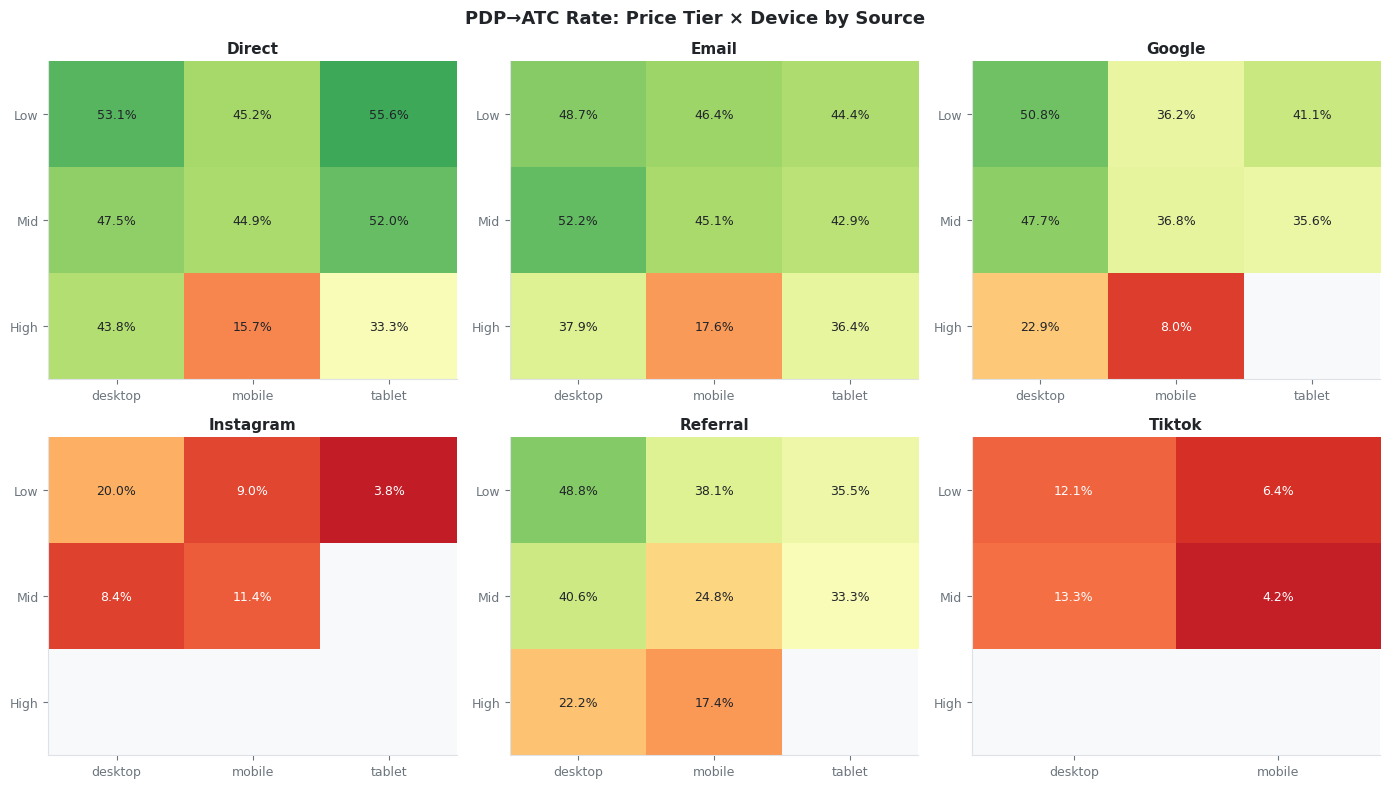


💡 Worst performing combination:
  Source: instagram | Tier: low | Device: tablet
  PDP→ATC: 3.8% | Sessions: 26 | Scroll: 0.16


In [11]:
print("=" * 65)
print("CROSS-TAB: SOURCE × PRICE TIER × DEVICE")
print("=" * 65)
print("""
The most granular segmentation in the analysis.
Identifies the specific intersection of:
  source × price tier × device
that has the worst PDP→ATC conversion.
This becomes the primary target audience for the A/B test.
""")

cross = (
    pdp.groupby(['traffic_source','price_tier','device_category'])
    .agg(
        sessions   = ('traffic_source',   'count'),
        atc        = ('reached_atc',      'sum'),
        purchased  = ('purchased',        'sum'),
        avg_scroll = ('avg_scroll_depth', 'mean'),
    )
    .reset_index()
)
cross['pdp_to_atc'] = cross['atc']       / cross['sessions']
cross['pdp_to_buy'] = cross['purchased'] / cross['sessions']

# Filter to meaningful segments
cross = cross[cross['sessions'] >= 20].copy()
cross['price_tier'] = pd.Categorical(
    cross['price_tier'], ['low','mid','high'])
cross = cross.sort_values('pdp_to_atc')

print("\nBOTTOM 10 — Lowest PDP→ATC combinations:")
display(cross.head(10)[[
    'traffic_source','price_tier','device_category',
    'sessions','pdp_to_atc','avg_scroll'
]].round(3))

print("\nTOP 10 — Highest PDP→ATC combinations:")
display(cross.tail(10)[[
    'traffic_source','price_tier','device_category',
    'sessions','pdp_to_atc','avg_scroll'
]].round(3))

# Heatmap: price tier × device for each source
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('PDP→ATC Rate: Price Tier × Device by Source',
             fontsize=13, fontweight='bold')

sources = sorted(pdp['traffic_source'].unique())
for ax, source in zip(axes.flatten(), sources):
    sub = cross[cross['traffic_source']==source]
    if len(sub) == 0:
        ax.axis('off')
        continue
    pivot = sub.pivot_table(
        index='price_tier',
        columns='device_category',
        values='pdp_to_atc',
        aggfunc='mean'
    ).reindex(['low','mid','high'])

    im = ax.imshow(pivot.values, cmap='RdYlGn',
                   aspect='auto', vmin=0.0, vmax=0.65)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([t.capitalize() for t in pivot.index], fontsize=9)
    ax.set_title(source.capitalize(), fontsize=11, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i,j]
            if not np.isnan(val):
                color = 'white' if val < 0.15 else '#212529'
                ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                        fontsize=9, color=color)

plt.tight_layout()
plt.savefig('../data/cross_tab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Worst combination
worst = cross.iloc[0]
print(f"\n💡 Worst performing combination:")
print(f"  Source: {worst['traffic_source']} | "
      f"Tier: {worst['price_tier']} | "
      f"Device: {worst['device_category']}")
print(f"  PDP→ATC: {worst['pdp_to_atc']:.1%} | "
      f"Sessions: {worst['sessions']:,} | "
      f"Scroll: {worst['avg_scroll']:.2f}")

In [12]:
print("=" * 68)
print("SEGMENTATION SUMMARY — KEY FINDINGS")
print("=" * 68)

# Pull key numbers
mobile_row  = device_seg[device_seg['device_category']=='mobile'].iloc[0]
desktop_row = device_seg[device_seg['device_category']=='desktop'].iloc[0]
email_row   = source_seg[source_seg['traffic_source']=='email'].iloc[0]
ig_row      = source_seg[source_seg['traffic_source']=='instagram'].iloc[0]
high_row    = tier_seg[tier_seg['price_tier']=='high'].iloc[0]
low_row     = tier_seg[tier_seg['price_tier']=='low'].iloc[0]
vh_row      = intent_seg[intent_seg['intent_level']=='very_high'].iloc[0]
vl_row      = intent_seg[intent_seg['intent_level']=='very_low'].iloc[0]

print(f"""
1. DEVICE
   Mobile ATC:  {mobile_row['pdp_to_atc']:.1%} vs Desktop: {desktop_row['pdp_to_atc']:.1%}
   Gap:         {desktop_row['pdp_to_atc']-mobile_row['pdp_to_atc']:.1%} lower on mobile
   Mobile is    {mobile_row['traffic_share']:.1%} of all PDP sessions
   → Mobile is a scale problem — most traffic, worst conversion

2. TRAFFIC SOURCE
   Email ATC:   {email_row['pdp_to_atc']:.1%} vs Instagram: {ig_row['pdp_to_atc']:.1%}
   Email loses at PDP→ATC (high intent, reaches PDP, needs nudge)
   Social loses at Home Page (low intent, never reaches PDP)
   → Different stages require different interventions

3. PRICE TIER
   High ATC:    {high_row['pdp_to_atc']:.1%} vs Low: {low_row['pdp_to_atc']:.1%}
   Gap:         {low_row['pdp_to_atc']-high_row['pdp_to_atc']:.1%}
   High AOV:    ${high_row['aov']:.0f} vs Low: ${low_row['aov']:.0f}
   → High-price users are worth more but convert less
   → Highest revenue opportunity per converted session

4. INTENT LEVEL (new dimension)
   Very High ATC: {vh_row['pdp_to_atc']:.1%} vs Very Low: {vl_row['pdp_to_atc']:.1%}
   Gap:           {vh_row['pdp_to_atc']-vl_row['pdp_to_atc']:.1%}
   → Intent level is the strongest single predictor of conversion
   → Upstream targeting (bringing in higher-intent users) has
     the same effect as improving the PDP itself

5. WORST INTERSECTION
   {worst['traffic_source'].capitalize()} × {worst['price_tier']} × {worst['device_category']}
   ATC: {worst['pdp_to_atc']:.1%} — lowest performing combination
   → This is the primary A/B test target population

6. DROP-OFF REASON DISTRIBUTION VARIES BY SEGMENT
   High-price sessions dominated by decision_friction
   Social sessions dominated by impulse_faded + price_shock
   → Value messaging works best for high-price + high-intent
   → Social traffic needs upstream fixes not PDP fixes
""")
print("=" * 68)
print("→ Next: 04_hypothesis.ipynb")

SEGMENTATION SUMMARY — KEY FINDINGS

1. DEVICE
   Mobile ATC:  37.7% vs Desktop: 43.9%
   Gap:         6.2% lower on mobile
   Mobile is    56.6% of all PDP sessions
   → Mobile is a scale problem — most traffic, worst conversion

2. TRAFFIC SOURCE
   Email ATC:   45.5% vs Instagram: 11.5%
   Email loses at PDP→ATC (high intent, reaches PDP, needs nudge)
   Social loses at Home Page (low intent, never reaches PDP)
   → Different stages require different interventions

3. PRICE TIER
   High ATC:    25.5% vs Low: 41.8%
   Gap:         16.3%
   High AOV:    $65 vs Low: $39
   → High-price users are worth more but convert less
   → Highest revenue opportunity per converted session

4. INTENT LEVEL (new dimension)
   Very High ATC: 47.3% vs Very Low: 7.1%
   Gap:           40.2%
   → Intent level is the strongest single predictor of conversion
   → Upstream targeting (bringing in higher-intent users) has
     the same effect as improving the PDP itself

5. WORST INTERSECTION
   Instagram × 